# MFCC-based Speaker Recognition — CNN Model Training

Loads pre-generated MFCC dataset splits from `MFCC_datasets/` and trains a CNN classifier for speaker recognition.

**Prerequisites:** Run `MFCC_dataset_generation.ipynb` first (including the *Dataset Export* cell) to produce:
- `MFCC_datasets/train_batches/`
- `MFCC_datasets/validation_batches/`
- `MFCC_datasets/test_batches/`
- `MFCC_datasets/element_spec.pkl`
- `MFCC_datasets/metadata.json`

In [12]:
import tensorflow as tf
import matplotlib.pyplot as plt
import librosa
import librosa.display
import pickle
import numpy as np
import os
import pandas as pd
import seaborn as sns
import json

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    InputLayer, BatchNormalization
)
from tensorflow.keras.optimizers import Adam

## Configuration

In [13]:
# Random seed for reproducibility
random_seed = 55
rng = np.random.default_rng(random_seed)
tf.random.set_seed(random_seed)

## Dataset Loading

In [15]:
DATASETS_PATH = "MFCC_datasets"
METADATA_PATH = os.path.join(DATASETS_PATH, "metadata.json")

if os.path.exists(METADATA_PATH):
    with open(METADATA_PATH, "r") as f:
        metadata = json.load(f)
    MFCC_input_shape = tuple(metadata["MFCC_input_shape"])
    NUM_CLASSES      = metadata["num_classes"]
    N_MFCC           = metadata.get("N_MFCC", 20)
    MFCC_FRAMES      = metadata.get("MFCC_FRAMES")
    SAMPLING_FREQ    = metadata.get("SAMPLING_FREQ", 48000)
    batch_size       = metadata.get("batch_size", 32)
    subfolders       = metadata.get("subfolders", [])
    unique_labels    = metadata.get("labels", [])
    print("Metadata loaded from metadata.json")
else:
    # Fallback: infer parameters from the dataset after loading
    print("Warning: metadata.json not found. Parameters will be inferred from the dataset.")
    N_MFCC        = 20
    SAMPLING_FREQ = 48000
    batch_size    = 32
    subfolders    = []
    MFCC_input_shape = None
    NUM_CLASSES      = None

print(f"  MFCC input shape : {MFCC_input_shape}")
print(f"  Num classes      : {NUM_CLASSES}")
print(f"  N_MFCC           : {N_MFCC}")
print(f"  MFCC_FRAMES      : {MFCC_FRAMES}")
print(f"  Sampling freq    : {SAMPLING_FREQ} Hz")
print(f"  Batch size       : {batch_size}")
print(f"  Classes          : {subfolders}")

Metadata loaded from metadata.json
  MFCC input shape : (20, 282, 2)
  Num classes      : 10
  N_MFCC           : 20
  MFCC_FRAMES      : 282
  Sampling freq    : 48000 Hz
  Batch size       : 32
  Classes          : ['f0001', 'f0002', 'f0003', 'f0004', 'f0005', 'm0001', 'm0002', 'm0003', 'm0004', 'm0005']


In [16]:
# Load element specs saved by MFCC_dataset_generation.ipynb
SPEC_PATH = os.path.join(DATASETS_PATH, "element_spec.pkl")
with open(SPEC_PATH, "rb") as f:
    specs = pickle.load(f)

MFCC_dataset_train_batches = tf.data.Dataset.load(
    os.path.join(DATASETS_PATH, "train_batches"),
    element_spec=specs["train"]
).prefetch(tf.data.AUTOTUNE)

MFCC_dataset_validation_batches = tf.data.Dataset.load(
    os.path.join(DATASETS_PATH, "validation_batches"),
    element_spec=specs["validation"]
).prefetch(tf.data.AUTOTUNE)

MFCC_dataset_test_batches = tf.data.Dataset.load(
    os.path.join(DATASETS_PATH, "test_batches"),
    element_spec=specs["test"]
).prefetch(tf.data.AUTOTUNE)

print(f"Train batches      : {MFCC_dataset_train_batches.cardinality().numpy()}")
print(f"Validation batches : {MFCC_dataset_validation_batches.cardinality().numpy()}")
print(f"Test batches       : {MFCC_dataset_test_batches.cardinality().numpy()}")

# Verify shapes and infer missing parameters when metadata.json is absent
for data_batch, label_batch in MFCC_dataset_train_batches.take(1):
    print(f"\nData batch shape   : {data_batch.shape}")
    print(f"Labels batch shape : {label_batch.shape}")
    if MFCC_input_shape is None:
        MFCC_input_shape = tuple(data_batch.shape[1:])
        print(f"Inferred MFCC_input_shape: {MFCC_input_shape}")

# if NUM_CLASSES is None:
#     all_labels = np.concatenate([y.numpy() for _, y in MFCC_dataset_train_batches])
#     NUM_CLASSES = int(len(np.unique(all_labels)))
#     print(f"Inferred NUM_CLASSES: {NUM_CLASSES}")

Train batches      : 72
Validation batches : 16
Test batches       : 16

Data batch shape   : (32, 20, 282, 2)
Labels batch shape : (32,)


## CNN Model Definition

In [17]:
model_MFCC = Sequential([
    # input_shape seems to be depracated. Consider is 'shape' is causing problems
    InputLayer(shape=MFCC_input_shape),

    Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')
])

model_MFCC.summary()

LEARNING_RATE  = 1e-4
loss_function  = 'sparse_categorical_crossentropy'
metrics        = ['accuracy']

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model_MFCC.compile(
    optimizer=optimizer,
    loss=loss_function,
    metrics=metrics
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 20, 282, 32)    │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 20, 282, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 141, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 141, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 10, 141, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 70, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 22400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     2,867,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,888,106 (11.02 MB)

 Trainable params: 2,887,914 (11.02 MB)

 Non-trainable params: 192 (768.00 B)

## Model Training

In [18]:
class EpochModelSaver(tf.keras.callbacks.Callback):
    def __init__(self, model, path, every_n_epochs=5, prefix="ckpt"):
        super().__init__()
        os.makedirs(path, exist_ok=True)
        self.path          = path
        self.save_freq     = every_n_epochs
        self.prefix        = prefix
        self.model_to_save = model

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.save_freq == 0:
            save_path = os.path.join(self.path, f"{self.prefix}_epoch_{epoch + 1:03d}.h5")
            self.model_to_save.save(save_path)
            print(f"\nModelo guardado en: {save_path}")


early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)


def save_history(history, filename):
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            print(f"Appending to existing history file: {filename}")
            old_history = json.load(f)
            for key in history.history:
                old_history[key].extend(history.history[key])
    else:
        old_history = history.history

    with open(filename, 'w') as f:
        json.dump(old_history, f)


def load_history(filename):
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            print(f"Loading history from file: {filename}")
            return json.load(f)
    return {}

In [19]:
history_MFCC = model_MFCC.fit(
    MFCC_dataset_train_batches,
    epochs=100,
    validation_data=MFCC_dataset_validation_batches,
    callbacks=[early_stopping_callback]
)

# Save training history to CSV
pd.DataFrame.from_dict(history_MFCC.history).to_csv('MFCC_training_history.csv', index=False)

Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.2868 - loss: 2.1046 - val_accuracy: 0.2439 - val_loss: 2.2223
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.4312 - loss: 1.5801 - val_accuracy: 0.4776 - val_loss: 2.1114
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.5292 - loss: 1.3047 - val_accuracy: 0.4919 - val_loss: 1.8994
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.5940 - loss: 1.1164 - val_accuracy: 0.5305 - val_loss: 1.7055
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.6593 - loss: 0.9156 - val_accuracy: 0.6240 - val_loss: 1.3930
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.7145 - loss: 0.7829 - val_accuracy: 0.6524 - val_loss: 1.0471
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.7646 - loss: 0.6414 - val_accuracy: 0.7683 - val_loss: 0.7167
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.7955 - loss: 0.5697 - val_accuracy: 0.

## Model Evaluation

Max value for accuracy: 0.98738032579422
Max value for loss: 2.104626417160034
Max value for val_accuracy: 0.9959349632263184
Max value for val_loss: 2.222334384918213


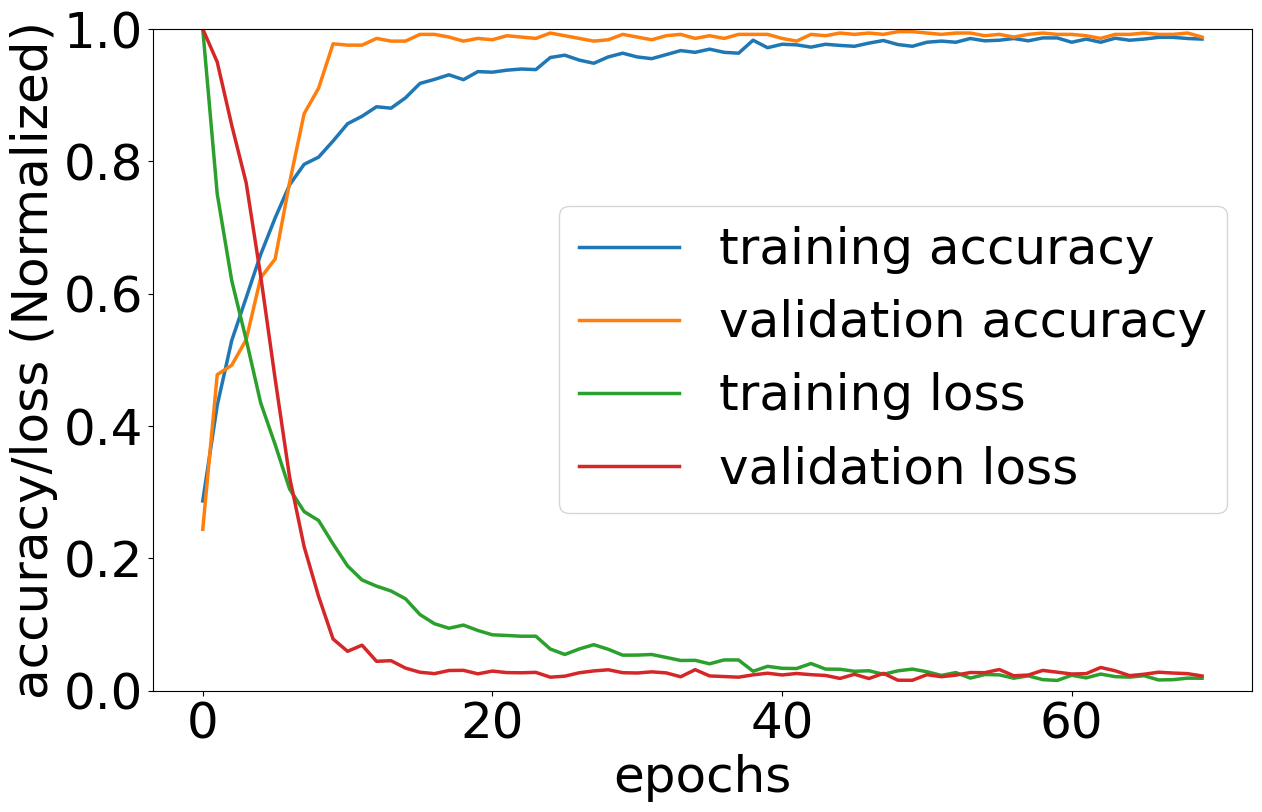

In [24]:
# Save training history to JSON (overwrites any previous run)
history_path = "training_history.json"
with open(history_path, 'w') as f:
    json.dump(history_MFCC.history, f)


def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicción')
    plt.ylabel('Realidad')
    plt.title('Matriz de Confusión')
    plt.show()


plt.rcParams.update({'font.size': 36})
plt.rcParams['lines.linewidth'] = 2.5


def new_cnn_plot_training_history_classification(history, metrics):
    fig_size         = 9
    fig_aspect_ratio = 3 / 2

    plt.figure(figsize=(fig_aspect_ratio * fig_size, fig_size))
    for i, metric in enumerate(metrics):
        if metric == 'loss':
            normalized_hist = {}
            total_max_val   = 0
            for key, values in history.items():
                max_val       = max(values)
                print(f"Max value for {key}: {max_val}")
                total_max_val = max(max_val, total_max_val)
                normalized_hist[key] = [val / total_max_val for val in values]
            history = normalized_hist
        plt.plot(history[f'{metric}'],     label=f'training {metric}')
        plt.plot(history[f'val_{metric}'], label=f'validation {metric}')
        plt.xlabel('epochs')
        plt.ylabel('accuracy/loss (Normalized)')
        plt.ylim([0, 1])
        plt.legend()

    plt.tight_layout()
    plt.show()


# Plot the most recent training run only
new_cnn_plot_training_history_classification(history_MFCC.history, metrics=['accuracy', 'loss'])

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9899 - loss: 0.0403 
Test Loss: 0.0403, Test Accuracy: 0.9899
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


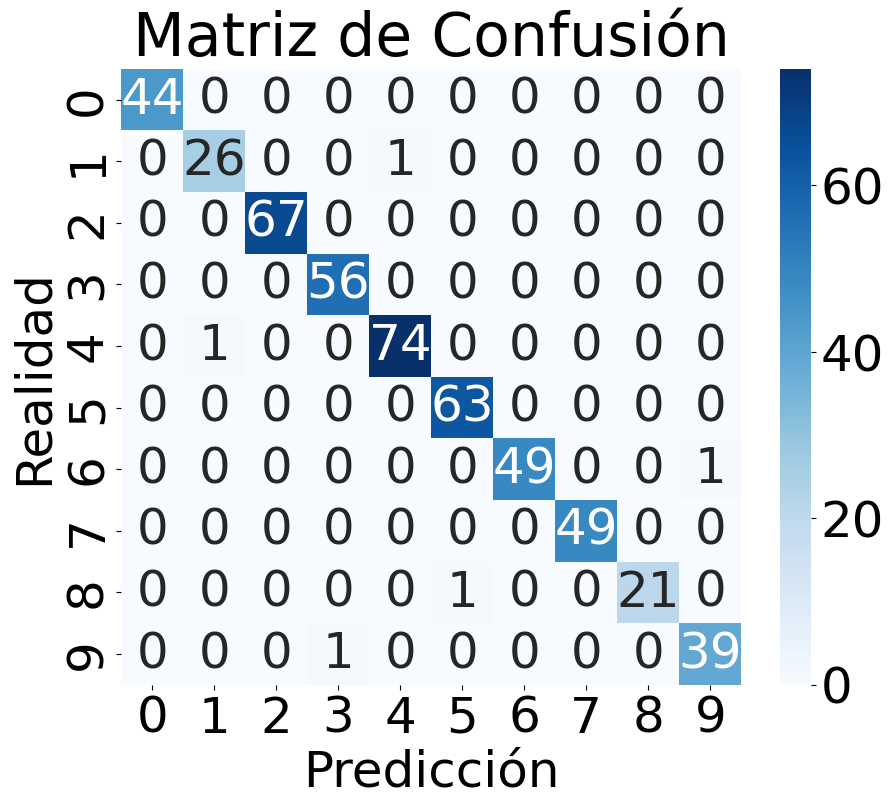


Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       0.96      0.96      0.96        27
           2       1.00      1.00      1.00        67
           3       0.98      1.00      0.99        56
           4       0.99      0.99      0.99        75
           5       0.98      1.00      0.99        63
           6       1.00      0.98      0.99        50
           7       1.00      1.00      1.00        49
           8       1.00      0.95      0.98        22
           9       0.97      0.97      0.97        40

    accuracy                           0.99       493
   macro avg       0.99      0.99      0.99       493
weighted avg       0.99      0.99      0.99       493



In [25]:
from sklearn.metrics import confusion_matrix, classification_report

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model_MFCC.evaluate(MFCC_dataset_test_batches)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Obtener las predicciones del conjunto de prueba
y_true = []
y_pred = []
for x_batch, y_batch in MFCC_dataset_test_batches:
    predictions = model_MFCC.predict(x_batch)
    y_true.extend(y_batch.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))


# Calcular la matriz de confusión
cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
# Graficar la matriz de confusión
plot_confusion_matrix(cm, labels=unique_labels)

# Crear etiquetas numéricas como strings para los reportes
integer_class_labels = [str(i) for i in range(NUM_CLASSES)]

# Reporte de Clasificación
print("\nReporte de Clasificación Detallado:")
print(classification_report(y_true, y_pred, target_names=integer_class_labels))